# Expoloratory Data Analysis

This notebook documents the exploratory analysis of the CIC IIoT 2025 (DataSense) dataset in preparation for federated learning experiments. The dataset uses a 10-second aggregation window to match the baseline evaluations in the DataSense paper (Table 8, Figures 12–15).

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
#from IPython.display import set_matplotlib_formats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

#re-run this later
#set_matplotlib_formats('retina', quality=100)

print("Libraries loaded.")

Libraries loaded.


---

## Dataset Loading and Merging

The attack and benign 10-second CSVs were concatenated into a single dataframe so that every row has a label (attack type or Benign). This unified format is required for both the centralized baseline and the federated partitioning pipeline.

In [10]:
# Merging attack and benign dataset

attack_df = pd.read_csv("../data/raw/attack_samples_10sec.csv")
benign_df = pd.read_csv("../data/raw/benign_samples_10sec.csv")
df = pd.concat([attack_df, benign_df], ignore_index=True)
df.to_csv("../data/processed/datasense_10sec_combined.csv", index=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 30,030 rows × 94 columns


---

## Schema Overview

Document every column, its dtype, and identify which columns are numeric vs. object (string/list). The DataSense dataset contains ~84 features plus label columns. List-type columns (e.g., "Ports All", "IPs Dst") are stored as strings and will need special handling.

In [11]:
print("=== Column Names & Types ===\n")
col_info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count(),
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
})
display(col_info)

# Separate numeric vs. object columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Object columns:  {len(object_cols)}")
print(f"\nObject columns (likely list-type or labels):\n{object_cols}")

=== Column Names & Types ===



,dtype,non_null,null_count,null_pct,n_unique
device_name,str,30030,0,0.0,38
device_mac,str,30030,0,0.0,38
label_full,str,30030,0,0.0,937
label1,str,30030,0,0.0,2
label2,str,30030,0,0.0,8
...,...,...,...,...,...
network_ttl_std_deviation,float64,30030,0,0.0,12116
network_window-size_avg,float64,30030,0,0.0,12784
network_window-size_max,float64,30030,0,0.0,199
network_window-size_min,float64,30030,0,0.0,479



Numeric columns: 71
Object columns:  23

Object columns (likely list-type or labels):
['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4', 'timestamp', 'timestamp_start', 'timestamp_end', 'log_data-types', 'network_ips_all', 'network_ips_dst', 'network_ips_src', 'network_macs_all', 'network_macs_dst', 'network_macs_src', 'network_ports_all', 'network_ports_dst', 'network_ports_src', 'network_protocols_all', 'network_protocols_dst', 'network_protocols_src']


---

## Label Columns

The dataset should have label columns for binary classification (Benign vs. Attack) and multi-class classification (8 categories: Benign, DDoS, DoS, Recon, MITM, Web, BruteForce, Malware). There may also be a fine-grained label with all 50 attack types.

In [23]:
for col in object_cols:
    if df[col].nunique() <= 100:  # label columns won't have thousands of unique values
        print(f"\n{col} — {df[col].nunique()} unique values:")
        print(df[col].value_counts().head(15))


device_name — 38 unique values:
device_name
edge1                   2037
mqtt-broker             2034
router                  1092
ap                       955
wisenet-camera           923
steam-sensor             892
weather-sensor           873
yi-camera                871
motion-sensor            870
light-sensor             822
water-sensor             822
gas-sensor               822
accelerometer-sensor     822
ultrasonic-sensor        822
sound-sensor             822
Name: count, dtype: int64

device_mac — 38 unique values:
device_mac
dc:a6:32:dc:27:d4    2037
dc:a6:32:dc:28:46    2034
28:87:ba:bd:c6:6c    1092
30:de:4b:e2:13:4e     955
00:09:18:6d:73:b9     923
08:b6:1f:81:d2:cc     892
08:b6:1f:82:12:30     873
7c:94:9f:84:71:7e     871
08:b6:1f:82:1c:3c     870
8c:aa:b5:8a:a9:b4     822
08:b6:1f:84:66:78     822
08:b6:1f:83:25:98     822
08:b6:1f:82:ee:44     822
08:b6:1f:82:ee:c4     822
f0:08:d1:ce:cf:c8     822
Name: count, dtype: int64

label1 — 2 unique values:
label1
a

By analyzing what value each label maps to, we can uncover the full label hierarchy:

- `label1` -> binary classification (attack/benign)
- `label2` -> 8-class classification of attack categories
- `label3` -> 50-class fine-grained label that has the specific attack name
- `label4` -> the attack category + attack name combined --- useful as a human-readable bridge between `label2` and `label3`
- `label_full` -> contains the full session descriptor including target devices --- useful for designing realistic non-IID partitions

| Attack Categories | No. of Attack Types | Attack Description |
| ----------------- | ------------------- | ------------------ |
| Reconnaissance | 9 | Host discovery, port scanning, OS fingerprinting, vulnerability scanning. These produced the most sensor log entries because they don't disrupt device operation. |
| DDoS | 15  | Coordinated floods from multiple bots: TCP SYN, UDP, ICMP, HTTP, ACK fragmentation, Slowloris, and others. Generated the highest packet volumes (~1.14 billion packets) |
| Dos  | 15  | Same flood techniques but from a single attacker (~538 million packets) |
| Man-in-the-Middle | 3  | ARP spoofing, IP spoofing, and device impersonation. |
| Web exploitation  | 5  | SQL injection, command injection, cross-site scripting, backdoor upload |
| Brute force | 2  | Dictionary attacks against SSH and Telnet services. |
| Malware | 2  | Actual Mirai botnet deployment with infection propagation followed by SYN flood and UDP flood attacks from compromised devices. |


In [ ]:
# Set label variables

LABEL_COL        = "label2"         # 8-class — primary target
LABEL_COL_BINARY = "label1"         # binary classification
LABEL_COL_FINE   = "label3"         # ~50 individual attack types
LABEL_COL_DETAIL = "label4"         # category_attack 
LABEL_COL_FULL   = "label_full"     # full session descriptor
DEVICE_COL       = "device_name"    # device list

---

## Class Distribution

The DataSense paper claims a balanced mix of benign and malicious traffic. It is important to verify the exact ratios here because class imblance will be amplified under non-IID federated partitioning

=== Class Distribution ===


,count,percent
label2,,
benign,13680,45.55
recon,6005,20.00
dos,3280,10.92
ddos,3234,10.77
mitm,1471,4.90
malware,1444,4.81
web,552,1.84
bruteforce,364,1.21


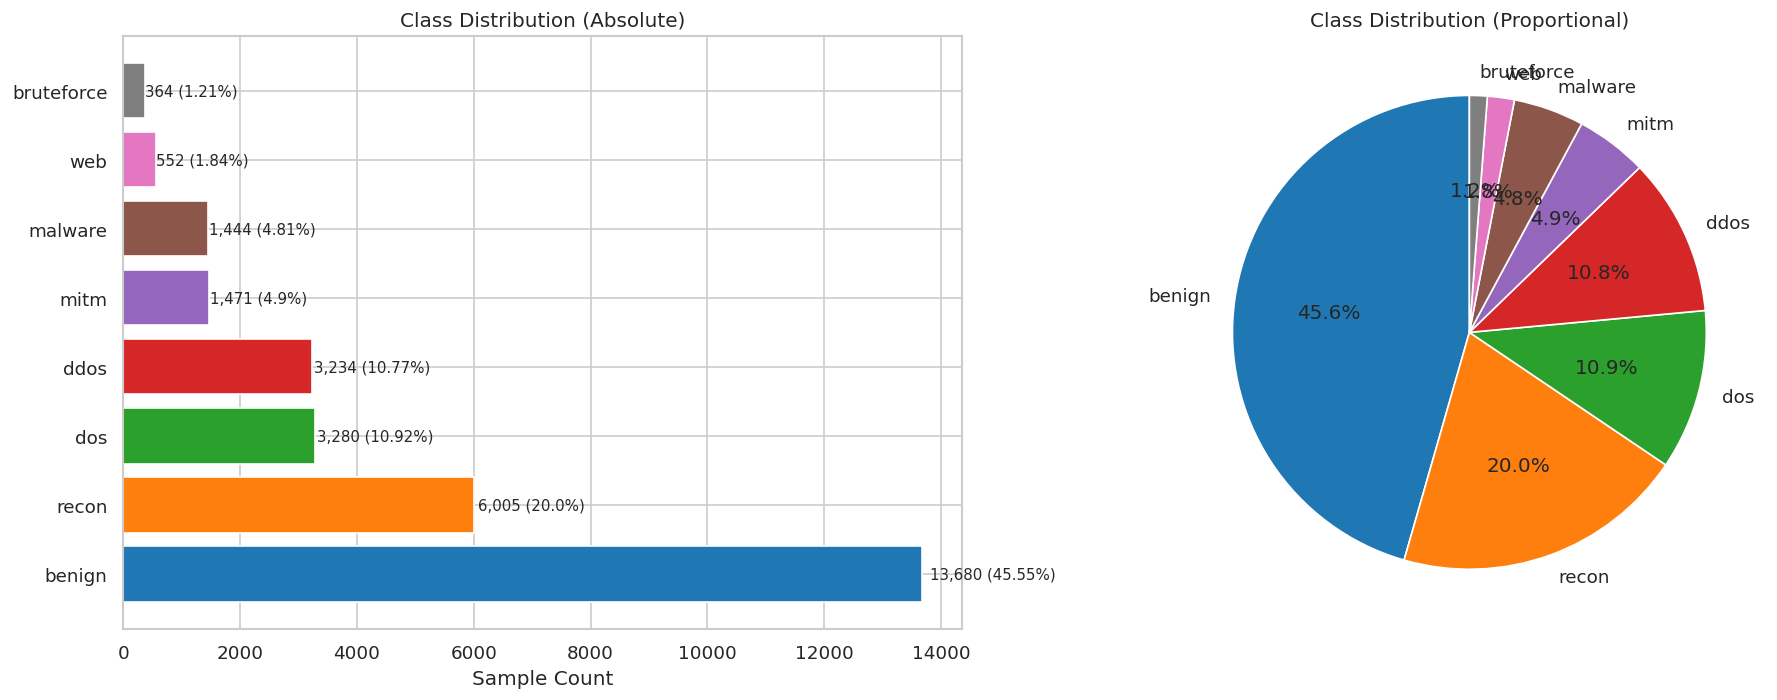


Expected 8 classes present: True
Actual unique labels: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']


In [26]:
class_counts = df[LABEL_COL].value_counts()
class_pcts = (class_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": class_counts, "percent": class_pcts})
print("=== Class Distribution ===")
display(summary)

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
axes[0].barh(class_counts.index, class_counts.values, color=sns.color_palette("tab10", len(class_counts)))
axes[0].set_xlabel("Sample Count")
axes[0].set_title("Class Distribution (Absolute)")
for i, (v, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    axes[0].text(v + v * 0.01, i, f"{v:,} ({pct}%)", va="center", fontsize=9)

# Percentage pie
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("tab10", len(class_counts)))
axes[1].set_title("Class Distribution (Proportional)")

plt.tight_layout()
plt.savefig("../results/eda_class_distribution.png", bbox_inches="tight")
plt.show()

# Check for the 8 expected categories
expected_classes = {"benign", "ddos", "dos", "recon", "mitm", "web", "bruteforce", "malware"}
actual_classes = set(df[LABEL_COL].unique())
print(f"\nExpected 8 classes present: {expected_classes.issubset(actual_classes)}")
print(f"Actual unique labels: {sorted(actual_classes)}")

---

## Missing Values & Data Quality

Check for NaN, infinite, and constant (zero-variance) columns. These values will be fed directly into `preprocessing.py`

In [ ]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)
if len(missing_cols) == 0:
    print("No missing values found.")
else:
    print(f"{len(missing_cols)} columns with missing values:")
    display(pd.DataFrame({
        "null_count": missing_cols,
        "null_pct": (missing_cols / len(df) * 100).round(2)
    }))

# Check for infinite values in numeric columns
print("\n=== Infinite Values ===")
inf_counts = {}
for col in numeric_cols:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_counts[col] = n_inf
if inf_counts:
    print(f"{len(inf_counts)} columns with infinite values:")
    for c, n in inf_counts.items():
        print(f"  {c}: {n}")
else:
    print("No infinite values found.")

# Constant columns (zero variance) — useless for classification
print("\n=== Zero-Variance (Constant) Columns ===")
constant_cols = [col for col in numeric_cols if df[col].nunique() <= 1]
if constant_cols:
    print(f"{len(constant_cols)} constant columns to drop: {constant_cols}")
else:
    print("No constant columns found.")

# Near-zero variance
print("\n=== Near-Zero Variance Columns (>99.9% single value) ===")
near_constant = []
for col in numeric_cols:
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    if top_pct > 99.9:
        near_constant.append((col, round(top_pct, 2)))
if near_constant:
    for c, p in near_constant:
        print(f"  {c}: {p}% single value")
else:
    print("None found.")